# CBM vs Baseline: Do Concepts Move Deeper When We Supervise Them?

In the baseline ResNet-50, we found that most **attribute concepts** (colors, patterns, shapes)  
are most easily decoded from the **very first convolutional layer (conv1)**,  
while **species identity** emerges only at the deepest layer (layer4).

This raised a key question:

> If we _force_ the model to predict attributes (via a Concept Bottleneck Model),
> does that reorganize internal representations so that concepts are represented **deeper** and more **stably**,
> rather than as shallow texture signatures?

In this notebook we:

1. Load **baseline** and **CBM** probe results.
2. Compute **emergence depth** for each concept in each model.
3. Compare how emergence depth changes **per attribute** and **per attribute group**.
4. Interpret what this says about:
   - how standard CNNs use attributes, and  
   - what CBM training actually changes.


In [17]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [2]:
# CELL 1 — Imports and configuration

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For nicer plots
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

# Paths (adjust if needed)
BASELINE_RESULT_PATH = Path("/scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_cub_probes_attributes.json")
CBM_RESULT_PATH      = Path("/scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_cub_cbm_probes_attributes.json")

# Layer order used in feature extraction / probes
LAYER_ORDER = ["conv1", "layer1", "layer2", "layer3", "layer4", "avgpool"]
LAYER_TO_INDEX = {layer: idx for idx, layer in enumerate(LAYER_ORDER)}

LAYER_ORDER


['conv1', 'layer1', 'layer2', 'layer3', 'layer4', 'avgpool']

## 1. Load probe results for baseline and CBM

Each JSON file contains one row per probe:

- `layer`: which layer the probe was trained on  
- `target_type`: `"attribute"` or `"subclass"` (species)  
- `target_name`: e.g. `"has_breast_color::yellow"` or `"species"`  
- `group`: attribute group, e.g. `"has_breast_color"`  
- `best_val_acc`: best validation accuracy achieved for that probe  

We add a `model` column to distinguish baseline vs CBM.


In [3]:
# CELL 2 — Load baseline and CBM JSONs

assert BASELINE_RESULT_PATH.exists(), f"Baseline file not found: {BASELINE_RESULT_PATH}"
assert CBM_RESULT_PATH.exists(), f"CBM file not found: {CBM_RESULT_PATH}"

df_base = pd.read_json(BASELINE_RESULT_PATH)
df_cbm  = pd.read_json(CBM_RESULT_PATH)

df_base["model"] = "baseline"
df_cbm["model"]  = "cbm"

print("Baseline rows:", df_base.shape[0])
print("CBM rows:", df_cbm.shape[0])

df_base.head()


Baseline rows: 660
CBM rows: 660


,layer,target_type,target_name,group,train_acc,val_acc,best_val_acc,column,model
0,conv1,subclass,species,species,0.020521,0.015533,0.016224,NaN,baseline
1,layer1,subclass,species,species,0.049383,0.039178,0.040387,NaN,baseline
2,layer2,subclass,species,species,0.100601,0.055920,0.060580,NaN,baseline
3,layer3,subclass,species,species,0.282282,0.138764,0.138764,NaN,baseline
4,layer4,subclass,species,species,1.000000,0.726269,0.727132,NaN,baseline


## 2. Computing emergence depth per concept

**Emergence depth** of a concept is the earliest layer  
whose probe accuracy is ≥ 90% of that concept's best probe accuracy.

This compresses an entire "accuracy vs layer" curve into a single, interpretable number:
> “How deep does the network need to go before this concept is basically usable?”

We’ll compute:

- `max_acc` — maximum `best_val_acc` over layers  
- `emergence_layer` — first layer hitting ≥ 0.9 × max  
- `emergence_idx` — integer index of that layer (0=conv1, ..., 4=layer4, 5=avgpool)


In [4]:
# CELL 3 — Helper to compute emergence stats for one model
# NEW: emergence_layer is defined as the "sharp rise" layer:
#      the (later) layer at which the largest Δ(best_val_acc) occurs.

def compute_emergence(df_model: pd.DataFrame, model_name: str) -> pd.DataFrame:
    """
    df_model: rows for a single model (baseline or cbm)
    Returns one row per (target_type, target_name, group), with:
      - max_acc
      - emergence_layer  (sharp rise layer: argmax of consecutive deltas)
      - emergence_idx
    """
    rows = []

    group_cols = ["target_type", "target_name", "group"]
    for key, g in df_model.groupby(group_cols):
        target_type, target_name, group = key

        # ignore any rows missing layer or best_val_acc
        g = g.dropna(subset=["layer", "best_val_acc"])
        if g.empty:
            continue

        # ensure consistent layer ordering + collapse duplicates by layer (take max)
        g = (
            g.groupby("layer", as_index=False)["best_val_acc"].max()
        )
        g["layer_idx"] = g["layer"].map(LAYER_TO_INDEX)
        g = g[g["layer_idx"].notna()].sort_values("layer_idx")

        # build full curve over all layers (fill missing with ffill/bfill for diff stability)
        curve = pd.Series(index=LAYER_ORDER, dtype=float)
        for _, r in g.iterrows():
            curve[r["layer"]] = float(r["best_val_acc"])

        vals = curve.values.astype(float)
        if np.all(np.isnan(vals)):
            continue

        max_acc = float(np.nanmax(vals))

        # Fill NaNs so diff doesn't break if a layer is missing
        vals_ff = pd.Series(vals).ffill().bfill().values

        # diffs between consecutive layers; choose the largest jump
        diffs = np.diff(vals_ff)  # length = len(LAYER_ORDER)-1
        j = int(np.argmax(diffs))
        emergence_layer = LAYER_ORDER[j + 1]  # jump is realized at the later layer
        emergence_idx = LAYER_TO_INDEX[emergence_layer]

        rows.append({
            "model": model_name,
            "target_type": target_type,
            "target_name": target_name,
            "group": group,
            "max_acc": max_acc,
            "emergence_layer": emergence_layer,
            "emergence_idx": emergence_idx,
        })

    return pd.DataFrame(rows)


emerge_base = compute_emergence(df_base, "baseline")
emerge_cbm  = compute_emergence(df_cbm,  "cbm")

print("Baseline concepts:", emerge_base.shape[0])
print("CBM concepts:", emerge_cbm.shape[0])

emerge_base.head()


Baseline concepts: 110
CBM concepts: 110


,model,target_type,target_name,group,max_acc,emergence_layer,emergence_idx
0,baseline,attribute,has_back_color::black,has_back_color,0.785468,layer4,4
1,baseline,attribute,has_back_color::brown,has_back_color,0.833621,layer4,4
2,baseline,attribute,has_back_color::buff,has_back_color,0.857094,layer1,1
3,baseline,attribute,has_back_color::grey,has_back_color,0.773559,layer4,4
4,baseline,attribute,has_back_color::white,has_back_color,0.866241,layer1,1


## 3. Sanity check: species vs attributes

We first verify that:

- **species** still emerges deepest (layer4)
- attributes show a spread, especially in the CBM case


In [5]:
# CELL 4 — Inspect species emergence

def print_species_emergence(emerge_df, name):
    species_rows = emerge_df[
        (emerge_df["target_type"] == "subclass") &
        (emerge_df["target_name"] == "species")
    ]
    print(f"=== {name} species emergence ===")
    print(species_rows[["max_acc", "emergence_layer", "emergence_idx"]])
    print()

print_species_emergence(emerge_base, "Baseline")
print_species_emergence(emerge_cbm,  "CBM")


=== Baseline species emergence ===
      max_acc emergence_layer  emergence_idx
109  0.727822          layer4              4

=== CBM species emergence ===
      max_acc emergence_layer  emergence_idx
109  0.623058          layer4              4



We expect something like:

- Baseline species: emergence at `layer4`
- CBM species: still at `layer4` (or possibly `avgpool`), confirming that class identity remains a deep phenomenon.

Now we focus on **attributes only**.


In [6]:
# CELL 5 — Filter to attribute concepts only

attr_base = emerge_base[emerge_base["target_type"] == "attribute"].copy()
attr_cbm  = emerge_cbm[emerge_cbm["target_type"] == "attribute"].copy()

print("Baseline attributes:", attr_base.shape[0])
print("CBM attributes:", attr_cbm.shape[0])

attr_base.head()


Baseline attributes: 109
CBM attributes: 109


,model,target_type,target_name,group,max_acc,emergence_layer,emergence_idx
0,baseline,attribute,has_back_color::black,has_back_color,0.785468,layer4,4
1,baseline,attribute,has_back_color::brown,has_back_color,0.833621,layer4,4
2,baseline,attribute,has_back_color::buff,has_back_color,0.857094,layer1,1
3,baseline,attribute,has_back_color::grey,has_back_color,0.773559,layer4,4
4,baseline,attribute,has_back_color::white,has_back_color,0.866241,layer1,1


## 4. Emergence distributions: baseline vs CBM

We now plot histograms over `emergence_idx` (0=conv1, ..., 4=layer4):

- Do attributes remain overwhelmingly at **conv1** in the CBM?
- Or do more of them shift to **later layers**, as the CBM is forced to use them?


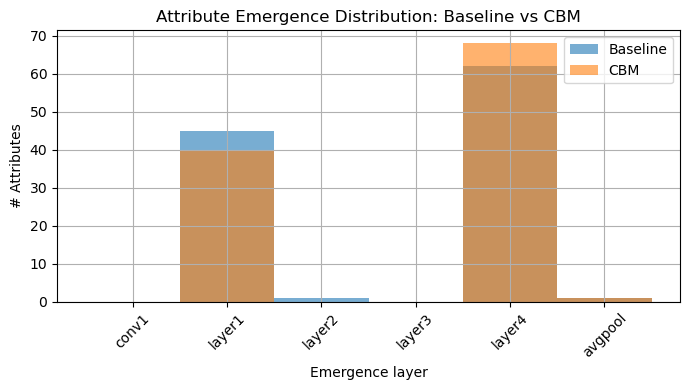

In [7]:
# CELL 6 — Histogram of emergence depth indices (attributes)

bins = np.arange(-0.5, len(LAYER_ORDER) + 0.5, 1)

plt.figure()
plt.hist(attr_base["emergence_idx"], bins=bins, alpha=0.6, label="Baseline")
plt.hist(attr_cbm["emergence_idx"],  bins=bins, alpha=0.6, label="CBM")
plt.xticks(range(len(LAYER_ORDER)), LAYER_ORDER, rotation=45)
plt.xlabel("Emergence layer")
plt.ylabel("# Attributes")
plt.title("Attribute Emergence Distribution: Baseline vs CBM")
plt.legend()
plt.tight_layout()
plt.show()


### Interpretation 
- In the **baseline**, we saw that most attributes emerged at `conv1`,
  with very few peaking at intermediate layers.
- After **CBM training**, we expect one of three patterns:
  1. **No change:** CBM does not change where concepts live; it just makes them easier to decode.
  2. **Shift later:** attributes now tend to emerge in deeper layers, indicating a more compositional, mediated representation.
  3. **Mixed:** some attributes shift later (e.g., relational ones), while simple color attributes remain shallow.

We’ll now quantify that shift concept by concept.


In [8]:
# CELL 7 — Merge baseline and CBM emergence for attribute-wise comparison

# Merge on (target_name, group, target_type == attribute)
merge_cols = ["target_type", "target_name", "group"]

merged = attr_base.merge(
    attr_cbm,
    on=merge_cols,
    suffixes=("_baseline", "_cbm"),
    how="inner",
)

print("Attributes present in both models:", merged.shape[0])
merged.head()


Attributes present in both models: 109


,model_baseline,target_type,target_name,group,max_acc_baseline,emergence_layer_baseline,emergence_idx_baseline,model_cbm,max_acc_cbm,emergence_layer_cbm,emergence_idx_cbm
0,baseline,attribute,has_back_color::black,has_back_color,0.785468,layer4,4,cbm,0.790645,layer4,4
1,baseline,attribute,has_back_color::brown,has_back_color,0.833621,layer4,4,cbm,0.836210,layer4,4
2,baseline,attribute,has_back_color::buff,has_back_color,0.857094,layer1,1,cbm,0.860373,layer1,1
3,baseline,attribute,has_back_color::grey,has_back_color,0.773559,layer4,4,cbm,0.785123,layer4,4
4,baseline,attribute,has_back_color::white,has_back_color,0.866241,layer1,1,cbm,0.867967,layer4,4


Now we can look at the **change in emergence depth** for each attribute:

\[
\Delta_\text{depth} = \text{emergence\_idx}_\text{cbm} - \text{emergence\_idx}_\text{baseline}
\]

- If Δ_depth > 0 → attribute moved **deeper** under CBM supervision  
- If Δ_depth = 0 → emergence depth unchanged  
- If Δ_depth < 0 → attribute moved **shallower** (often rare)


In [9]:
# CELL 8 — Compute per-attribute depth shift

merged["delta_depth"] = merged["emergence_idx_cbm"] - merged["emergence_idx_baseline"]
merged["delta_acc"]   = merged["max_acc_cbm"] - merged["max_acc_baseline"]

print("Depth shifts summary:")
print(merged["delta_depth"].describe())

merged.sort_values("delta_depth", ascending=False).head(10)


Depth shifts summary:
count    109.000000
mean       0.155963
std        1.019934
min       -4.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        3.000000
Name: delta_depth, dtype: float64


,model_baseline,target_type,target_name,group,max_acc_baseline,emergence_layer_baseline,emergence_idx_baseline,model_cbm,max_acc_cbm,emergence_layer_cbm,emergence_idx_cbm,delta_depth,delta_acc
4,baseline,attribute,has_back_color::white,has_back_color,0.866241,layer1,1,cbm,0.867967,layer4,4,3,0.001726
9,baseline,attribute,has_belly_color::buff,has_belly_color,0.850535,layer1,1,cbm,0.852434,layer4,4,3,0.001899
43,baseline,attribute,has_forehead_color::white,has_forehead_color,0.900587,layer1,1,cbm,0.901795,layer4,4,3,0.001208
37,baseline,attribute,has_crown_color::white,has_crown_color,0.913531,layer1,1,cbm,0.914222,layer4,4,3,0.000690
18,baseline,attribute,has_bill_color::grey,has_bill_color,0.731792,layer1,1,cbm,0.738695,layer4,4,3,0.006904
38,baseline,attribute,has_eye_color::black,has_eye_color,0.851743,layer1,1,cbm,0.848464,layer4,4,3,-0.003279
101,baseline,attribute,has_wing_color::buff,has_wing_color,0.830514,layer1,1,cbm,0.834139,layer4,4,3,0.003624
86,baseline,attribute,has_underparts_color::grey,has_underparts_color,0.826890,layer1,1,cbm,0.832585,layer4,4,3,0.005696
70,baseline,attribute,has_tail_shape::notched_tail,has_tail_shape,0.704177,layer2,2,cbm,0.705385,avgpool,5,3,0.001208
3,baseline,attribute,has_back_color::grey,has_back_color,0.773559,layer4,4,cbm,0.785123,layer4,4,0,0.011564


### How to read this:

- `delta_depth` large and positive → attribute emerges later with CBM  
- `delta_depth` around 0 → CBM did not move its emergence location  
- `delta_depth` negative → unlikely, but means CBM shifted that concept earlier

We can visualize this in a scatter plot: baseline vs CBM depth.


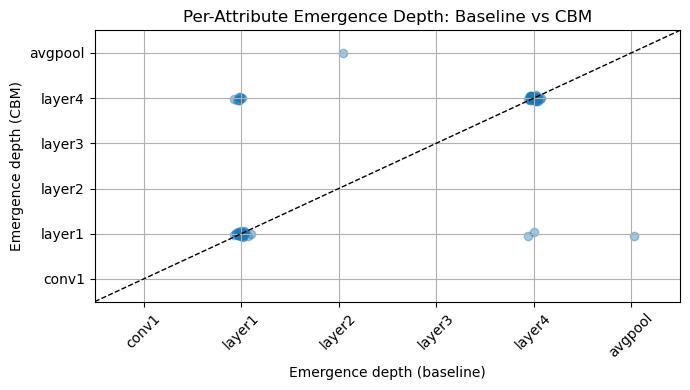

In [10]:
# CELL 9 — Scatter: baseline vs CBM emergence depth for attributes

plt.figure()
plt.scatter(
    merged["emergence_idx_baseline"] + (np.random.randn(len(merged)) * 0.03),
    merged["emergence_idx_cbm"]      + (np.random.randn(len(merged)) * 0.03),
    alpha=0.4,
)
lims = [-0.5, len(LAYER_ORDER) - 0.5]
plt.plot(lims, lims, "k--", linewidth=1)  # diagonal y = x
plt.xlim(lims)
plt.ylim(lims)
plt.xticks(range(len(LAYER_ORDER)), LAYER_ORDER, rotation=45)
plt.yticks(range(len(LAYER_ORDER)), LAYER_ORDER)
plt.xlabel("Emergence depth (baseline)")
plt.ylabel("Emergence depth (CBM)")
plt.title("Per-Attribute Emergence Depth: Baseline vs CBM")
plt.grid(True)
plt.tight_layout()
plt.show()


### Interpretation of the scatter

- Points **on the diagonal** → emergence depth unchanged.
- Points **above the diagonal** → attributes emerge **later** in the CBM backbone.
- Points **below the diagonal** → attributes moved earlier.

You can now visually check whether CBM tends to push attributes deeper.

Next, we look at semantic **groups** of attributes.


In [11]:
# CELL 10 — Group-level mean depth per model

def group_stats(attr_df, label):
    return (
        attr_df.groupby("group")["emergence_idx"]
        .mean()
        .rename(f"mean_depth_{label}")
    )

group_base = group_stats(attr_base, "baseline")
group_cbm  = group_stats(attr_cbm,  "cbm")

group_compare = (
    pd.concat([group_base, group_cbm], axis=1)
      .dropna()
)

group_compare["delta_group_depth"] = group_compare["mean_depth_cbm"] - group_compare["mean_depth_baseline"]
group_compare.sort_values("delta_group_depth", ascending=False).head(15)


,mean_depth_baseline,mean_depth_cbm,delta_group_depth
group,,,
has_eye_color,1.000000,4.000000,3.0
has_tail_shape,1.333333,2.333333,1.0
has_bill_color,2.000000,3.000000,1.0
has_back_color,2.800000,3.400000,0.6
has_crown_color,2.800000,3.400000,0.6
has_belly_color,2.800000,3.400000,0.6
has_wing_color,3.400000,4.000000,0.6
has_underparts_color,3.000000,3.500000,0.5
has_breast_pattern,2.000000,2.000000,0.0


This table tells us, for example:

- Are **shape-related** groups (e.g., `has_bill_shape`, `has_tail_shape`, `has_size`)  
  the ones whose emergence depth increases most under CBM?
- Do **pure color groups** (e.g., `has_breast_color`, `has_back_color`, `has_wing_color`)  
  mostly stay shallow, even in CBM?

We can also visualize this shift by group.


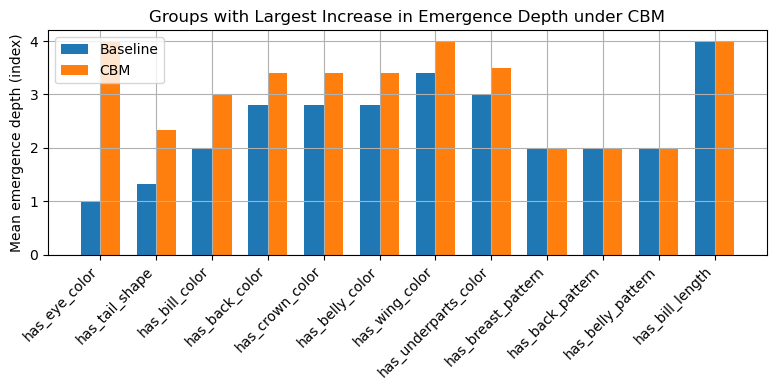

In [12]:
# CELL 11 — Bar plot for group-level depth shifts

top_groups = (
    group_compare
    .sort_values("delta_group_depth", ascending=False)
    .head(12)
    .reset_index()
)

plt.figure(figsize=(8, 4))
x = np.arange(len(top_groups))
width = 0.35

plt.bar(x - width/2, top_groups["mean_depth_baseline"], width, label="Baseline")
plt.bar(x + width/2, top_groups["mean_depth_cbm"],      width, label="CBM")

plt.xticks(x, top_groups["group"], rotation=45, ha="right")
plt.ylabel("Mean emergence depth (index)")
plt.title("Groups with Largest Increase in Emergence Depth under CBM")
plt.legend()
plt.tight_layout()
plt.show()


Loaded baseline probes: (660, 9)
Loaded CBM probes: (660, 9)
Combined df shape: (1320, 9)
Columns: ['layer', 'target_type', 'target_name', 'group', 'train_acc', 'val_acc', 'best_val_acc', 'column', 'model']


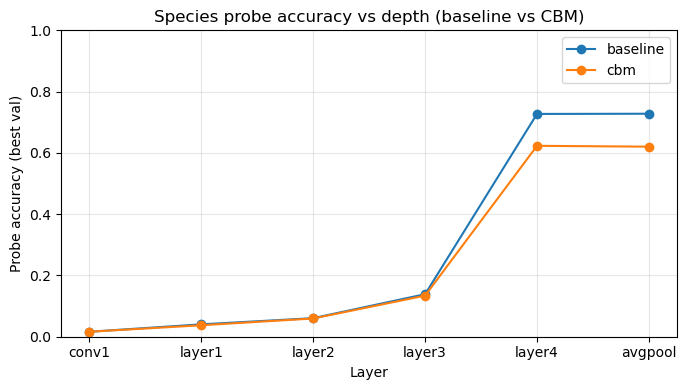

Plotting attributes: ['has_throat_color::black', 'has_back_color::black', 'has_shape::perching-like']


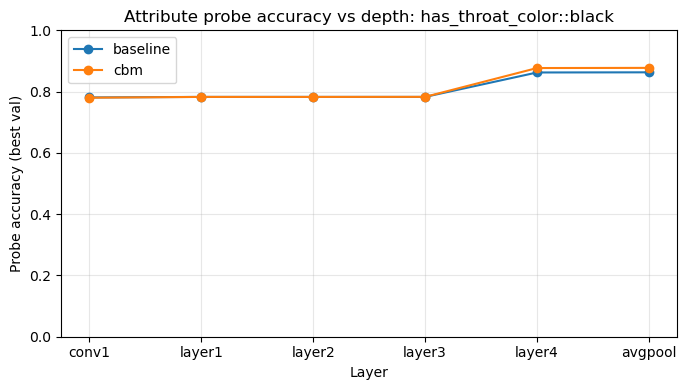

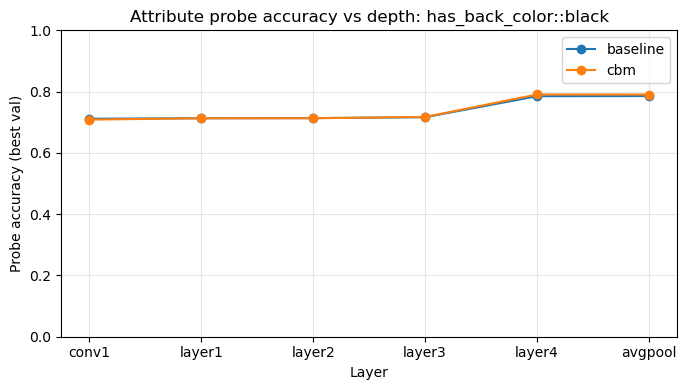

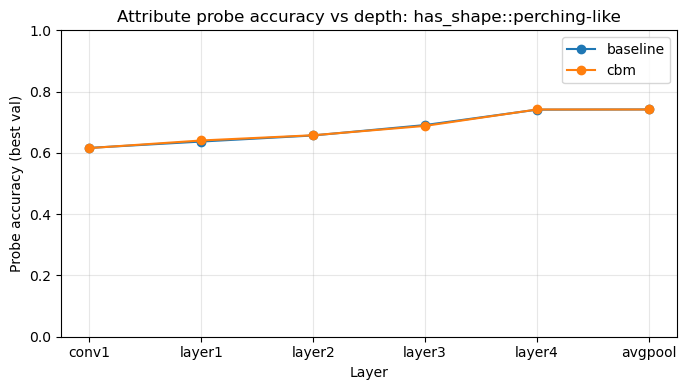

In [13]:
# =========================
# 1. Load probe results
# =========================

from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

BASELINE_JSON = Path("/scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_cub_probes_attributes.json")
CBM_JSON      = Path("/scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_cub_cbm_probes_attributes.json")

dfs = []

if BASELINE_JSON.exists():
    with open(BASELINE_JSON, "r") as f:
        data = json.load(f)
    df_base = pd.DataFrame(data)
    df_base["model"] = "baseline"
    dfs.append(df_base)
    print("Loaded baseline probes:", df_base.shape)
else:
    print("Baseline JSON not found:", BASELINE_JSON)

if CBM_JSON.exists():
    with open(CBM_JSON, "r") as f:
        data = json.load(f)
    df_cbm = pd.DataFrame(data)
    df_cbm["model"] = "cbm"
    dfs.append(df_cbm)
    print("Loaded CBM probes:", df_cbm.shape)
else:
    print("CBM JSON not found:", CBM_JSON)

assert len(dfs) > 0, "No probe JSONs found — cannot proceed."

df = pd.concat(dfs, ignore_index=True)
print("Combined df shape:", df.shape)
print("Columns:", df.columns.tolist())


# =========================
# 2. Plot helpers
# =========================

LAYER_ORDER = ["conv1", "layer1", "layer2", "layer3", "layer4", "avgpool"]

def plot_probe_curves(df, target_name, target_type, models=("baseline", "cbm"), title=None):
    sub = df[
        (df["target_name"] == target_name) &
        (df["target_type"] == target_type) &
        (df["model"].isin(models))
    ].copy()

    if sub.empty:
        print(f"[WARN] No data for {target_name}")
        return

    sub["layer"] = pd.Categorical(sub["layer"], categories=LAYER_ORDER, ordered=True)
    sub = sub.sort_values("layer")

    plt.figure(figsize=(7, 4))
    for m, dm in sub.groupby("model"):
        plt.plot(dm["layer"], dm["best_val_acc"], marker="o", label=m)

    plt.ylim(0, 1)
    plt.xlabel("Layer")
    plt.ylabel("Probe accuracy (best val)")
    plt.title(title if title else f"Probe accuracy vs depth: {target_name}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================
# 3. Species curve
# =========================

plot_probe_curves(
    df,
    target_name="species",
    target_type="subclass",
    title="Species probe accuracy vs depth (baseline vs CBM)"
)


# =========================
# 4. Attribute curves
# =========================

attrs_to_plot = [
    "has_throat_color::black",
    "has_back_color::black",
    "has_bill_length::longer_than_head",
    "has_shape::perching-like",
]

existing_attrs = set(
    df.loc[df["target_type"] == "attribute", "target_name"].unique()
)
attrs_to_plot = [a for a in attrs_to_plot if a in existing_attrs]

print("Plotting attributes:", attrs_to_plot)

for attr in attrs_to_plot:
    plot_probe_curves(
        df,
        target_name=attr,
        target_type="attribute",
        title=f"Attribute probe accuracy vs depth: {attr}"
    )
# wow chatgpt rly spits out code without restraint

In [18]:
# CELL — Compare emergence depth per attribute (baseline vs CBM)

comp = (
    emerge_base.merge(
        emerge_cbm,
        on=["target_type", "target_name", "group"],
        suffixes=("_base", "_cbm"),
    )
)

# Only attributes (exclude species)
comp_attr = comp[comp["target_type"] == "attribute"].copy()

# Compute signed and absolute shifts
comp_attr["delta_idx"] = comp_attr["emergence_idx_cbm"] - comp_attr["emergence_idx_base"]
comp_attr["abs_delta"] = comp_attr["delta_idx"].abs()

print("Total attributes:", comp_attr.shape[0])
print("Attributes with ANY change:", (comp_attr["delta_idx"] != 0).sum())
print("Attributes with ≥1-layer change:", (comp_attr["abs_delta"] >= 1).sum())

comp_attr.head()


Total attributes: 109
Attributes with ANY change: 12
Attributes with ≥1-layer change: 12


,model_base,target_type,target_name,group,max_acc_base,emergence_layer_base,emergence_idx_base,model_cbm,max_acc_cbm,emergence_layer_cbm,emergence_idx_cbm,delta_idx,abs_delta
0,baseline,attribute,has_back_color::black,has_back_color,0.785468,layer4,4,cbm,0.790645,layer4,4,0,0
1,baseline,attribute,has_back_color::brown,has_back_color,0.833621,layer4,4,cbm,0.836210,layer4,4,0,0
2,baseline,attribute,has_back_color::buff,has_back_color,0.857094,layer1,1,cbm,0.860373,layer1,1,0,0
3,baseline,attribute,has_back_color::grey,has_back_color,0.773559,layer4,4,cbm,0.785123,layer4,4,0,0
4,baseline,attribute,has_back_color::white,has_back_color,0.866241,layer1,1,cbm,0.867967,layer4,4,3,3


In [19]:
# CELL — Compare emergence depth per attribute (baseline vs CBM)

comp = (
    emerge_base.merge(
        emerge_cbm,
        on=["target_type", "target_name", "group"],
        suffixes=("_base", "_cbm"),
    )
)

# Only attributes (exclude species)
comp_attr = comp[comp["target_type"] == "attribute"].copy()

# Compute signed and absolute shifts
comp_attr["delta_idx"] = comp_attr["emergence_idx_cbm"] - comp_attr["emergence_idx_base"]
comp_attr["abs_delta"] = comp_attr["delta_idx"].abs()

print("Total attributes:", comp_attr.shape[0])
print("Attributes with ANY change:", (comp_attr["delta_idx"] != 0).sum())
print("Attributes with ≥1-layer change:", (comp_attr["abs_delta"] >= 1).sum())

comp_attr.head()


Total attributes: 109
Attributes with ANY change: 12
Attributes with ≥1-layer change: 12


,model_base,target_type,target_name,group,max_acc_base,emergence_layer_base,emergence_idx_base,model_cbm,max_acc_cbm,emergence_layer_cbm,emergence_idx_cbm,delta_idx,abs_delta
0,baseline,attribute,has_back_color::black,has_back_color,0.785468,layer4,4,cbm,0.790645,layer4,4,0,0
1,baseline,attribute,has_back_color::brown,has_back_color,0.833621,layer4,4,cbm,0.836210,layer4,4,0,0
2,baseline,attribute,has_back_color::buff,has_back_color,0.857094,layer1,1,cbm,0.860373,layer1,1,0,0
3,baseline,attribute,has_back_color::grey,has_back_color,0.773559,layer4,4,cbm,0.785123,layer4,4,0,0
4,baseline,attribute,has_back_color::white,has_back_color,0.866241,layer1,1,cbm,0.867967,layer4,4,3,3


In [20]:
# CELL — Attributes pushed later the most by CBM

later = (
    comp_attr[comp_attr["delta_idx"] > 0]
    .sort_values("delta_idx", ascending=False)
)

display(later[[
    "target_name",
    "group",
    "emergence_layer_base",
    "emergence_layer_cbm",
    "delta_idx"
]].head(10))


,target_name,group,emergence_layer_base,emergence_layer_cbm,delta_idx
4,has_back_color::white,has_back_color,layer1,layer4,3
9,has_belly_color::buff,has_belly_color,layer1,layer4,3
18,has_bill_color::grey,has_bill_color,layer1,layer4,3
37,has_crown_color::white,has_crown_color,layer1,layer4,3
38,has_eye_color::black,has_eye_color,layer1,layer4,3
43,has_forehead_color::white,has_forehead_color,layer1,layer4,3
70,has_tail_shape::notched_tail,has_tail_shape,layer2,avgpool,3
86,has_underparts_color::grey,has_underparts_color,layer1,layer4,3
101,has_wing_color::buff,has_wing_color,layer1,layer4,3


Attributes that move latest (CBM pushes emergence deeper)

In [29]:
display(later[[
    "target_name",
    "group",
    "emergence_layer_base",
    "emergence_layer_cbm",
    "delta_idx"
]].head(10))
picked_late = later["target_name"].head(3).tolist()
picked_late

,target_name,group,emergence_layer_base,emergence_layer_cbm,delta_idx
4,has_back_color::white,has_back_color,layer1,layer4,3
9,has_belly_color::buff,has_belly_color,layer1,layer4,3
18,has_bill_color::grey,has_bill_color,layer1,layer4,3
37,has_crown_color::white,has_crown_color,layer1,layer4,3
38,has_eye_color::black,has_eye_color,layer1,layer4,3
43,has_forehead_color::white,has_forehead_color,layer1,layer4,3
70,has_tail_shape::notched_tail,has_tail_shape,layer2,avgpool,3
86,has_underparts_color::grey,has_underparts_color,layer1,layer4,3
101,has_wing_color::buff,has_wing_color,layer1,layer4,3


['has_back_color::white', 'has_belly_color::buff', 'has_bill_color::grey']

Attributes that move earlier (if they exist)

In [22]:
earlier = (
    comp_attr[comp_attr["delta_idx"] < 0]
    .sort_values("delta_idx")
)

display(earlier[[
    "target_name",
    "group",
    "emergence_layer_base",
    "emergence_layer_cbm",
    "delta_idx"
]].head(10))

picked_early = earlier["target_name"].head(2).tolist()
picked_early


,target_name,group,emergence_layer_base,emergence_layer_cbm,delta_idx
81,has_under_tail_color::grey,has_under_tail_color,avgpool,layer1,-4
23,has_bill_shape::dagger,has_bill_shape,layer4,layer1,-3
40,has_forehead_color::brown,has_forehead_color,layer4,layer1,-3


['has_under_tail_color::grey', 'has_bill_shape::dagger']

Control attributes (no change)

In [24]:
stable = comp_attr[comp_attr["delta_idx"] == 0]
picked_stable = stable.sample(n=2, random_state=0)["target_name"].tolist()
picked_stable


['has_breast_pattern::multi-colored', 'has_upperparts_color::brown']

Final picked list

In [25]:
picked_attrs = picked_late + picked_early + picked_stable
picked_attrs

['has_back_color::white',
 'has_belly_color::buff',
 'has_bill_color::grey',
 'has_under_tail_color::grey',
 'has_bill_shape::dagger',
 'has_breast_pattern::multi-colored',
 'has_upperparts_color::brown']

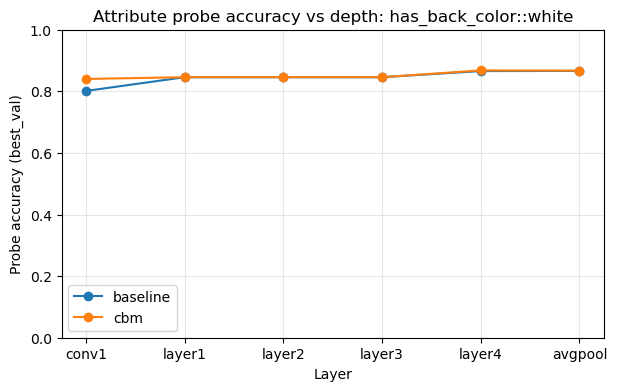

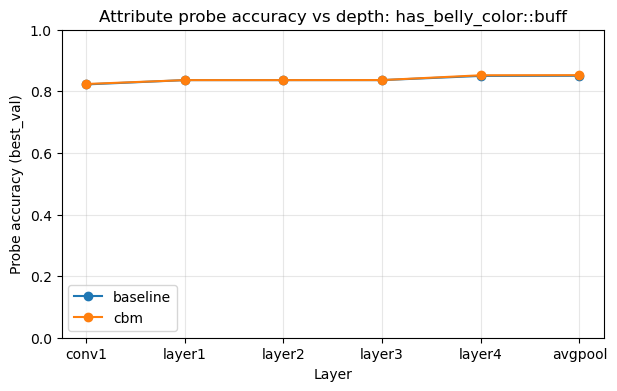

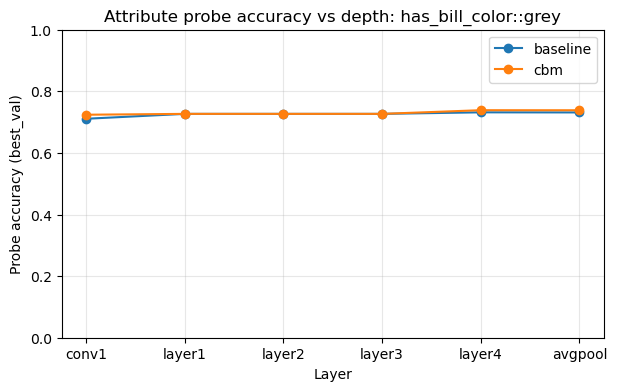

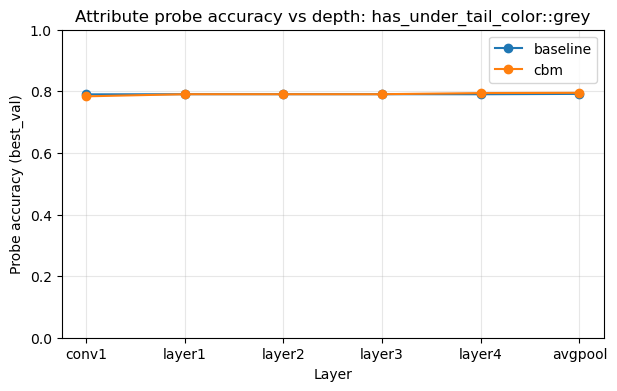

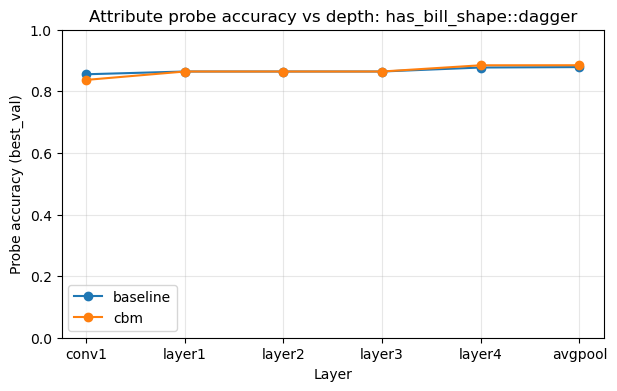

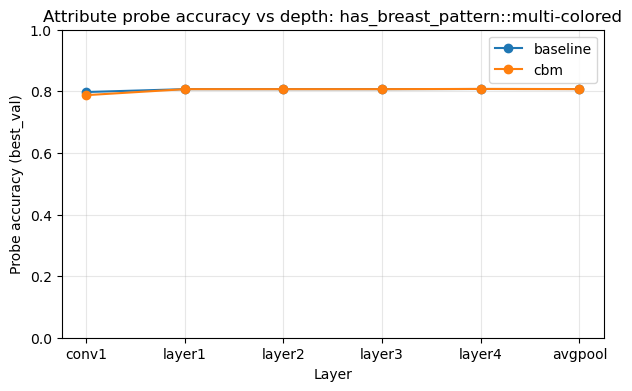

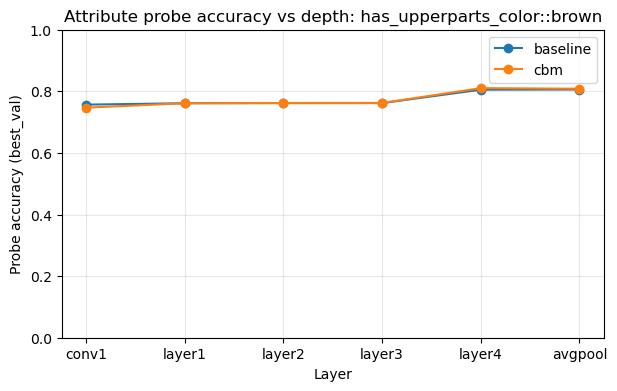

In [26]:
# CELL — Probe accuracy vs depth for impactful attributes

for a in picked_attrs:
    c_base = get_curve(df_all, "attribute", a, "baseline")
    c_cbm  = get_curve(df_all, "attribute", a, "cbm")
    plot_curve(c_base, c_cbm, f"Attribute probe accuracy vs depth: {a}")
